In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
import os
import re
import pandas as pd

root = r"C:\Users\cronk\.vscode\Sticky_Dumbbell_MS_Project\RDP_SF004"   # parent of the five sub‑folders
folders = sorted(
    os.path.join(root, d) for d in os.listdir(root)
    if os.path.isdir(os.path.join(root, d))
)

df_by_folder = {}        # will hold one DataFrame per folder

# regex to grab only the numeric part (e.g. 10, 15) from the DP pattern
dp_re = re.compile(r"_(\d+)DP_")

for folder in folders:
    rows   = []          # list of one‑row DataFrames
    names  = []          # corresponding file names for the index
    for fname in sorted(os.listdir(folder)):
        # only read the "_parameters.csv" files
        if not fname.lower().endswith("_goodness.csv"):
            continue
        path = os.path.join(folder, fname)
        df = pd.read_csv(path)          # each file is assumed to contain exactly one row
        if len(df) != 1:
            raise ValueError(f"{path!r} has {len(df)} rows; expected 1")
        # --- extract DP and add as column ---
        m = dp_re.search(fname)
        if m:
            df['DP'] = m.group(1)
        else:
            df['DP'] = pd.NA
        # --- option A: add filename as a column ---
        df['set'] = os.path.splitext(fname)[0]
        rows.append(df)
        # --- option B: use names list for a MultiIndex below ---

        names.append(os.path.splitext(fname)[0])

    if not rows:
        continue

    # vertical concatenation: 5 files → 5 rows
    combined = pd.concat(rows, ignore_index=True)

    # if you prefer the filename as the row index instead of a column:
    # combined = pd.concat(rows, keys=names, names=['set'])

    df_by_folder[os.path.basename(folder)] = combined

# inspect one folder
print(df_by_folder['RDP_SF004_05A_data'])

      R2_Gp    R2_Gpp  R2_total  R2_log_Gp  R2_log_Gpp  R2_log_total  \
0  0.989260  0.639860  0.983422   0.987603    0.734991      0.968223   
1  0.989554  0.683960  0.983544   0.988471    0.789040      0.971536   
2  0.989669  0.685792  0.983671   0.988544    0.791646      0.971894   
3  0.989938  0.663393  0.983537   0.987765    0.792274      0.971647   
4  0.989227  0.686692  0.983054   0.988670    0.791740      0.970970   

      RMSE_Gp    RMSE_Gpp  Reduced_chi2         AIC  DP  \
0  390.913690  408.560395      0.025226  247.642019  10   
1  383.360567  400.325057      0.022835  366.265701  15   
2  381.207280  399.179668      0.021692  485.352626  20   
3  374.615315  405.484558      0.021098  604.705709  25   
4  397.731786  414.843798      0.023276  752.903147  31   

                           set  
0  fit_SF004_05A_10DP_goodness  
1  fit_SF004_05A_15DP_goodness  
2  fit_SF004_05A_20DP_goodness  
3  fit_SF004_05A_25DP_goodness  
4  fit_SF004_05A_31DP_goodness  


In [27]:
df_by_folder['RDP_SF004_25A_data']

,R2_Gp,R2_Gpp,R2_total,R2_log_Gp,R2_log_Gpp,R2_log_total,RMSE_Gp,RMSE_Gpp,Reduced_chi2,AIC,DP,set
0,0.991203,0.870789,0.984464,0.989067,0.954502,0.984178,347.727466,370.390727,0.025145,243.359389,10,fit_SF004_25A.bbx_10DP_goodness
1,0.991012,0.880143,0.984012,0.988621,0.960093,0.984386,345.265465,368.167724,0.024420,360.647396,15,fit_SF004_25A.bbx_15DP_goodness
2,0.991066,0.880588,0.984081,0.988907,0.960571,0.984711,344.078993,367.434364,0.023071,477.982837,20,fit_SF004_25A.bbx_20DP_goodness
3,0.991174,0.886882,0.984719,0.988301,0.963568,0.984671,341.165721,354.007887,0.021912,593.118503,25,fit_SF004_25A.bbx_25DP_goodness
4,0.990586,0.872414,0.983343,0.988221,0.957872,0.983644,361.635787,384.832989,0.025096,742.413465,31,fit_SF004_25A.bbx_31DP_goodness


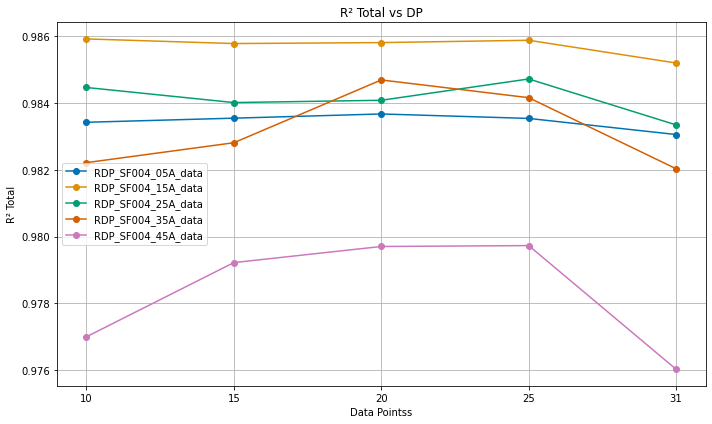

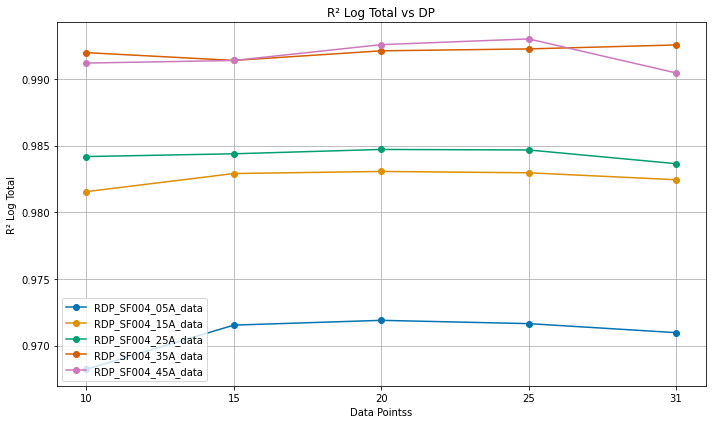

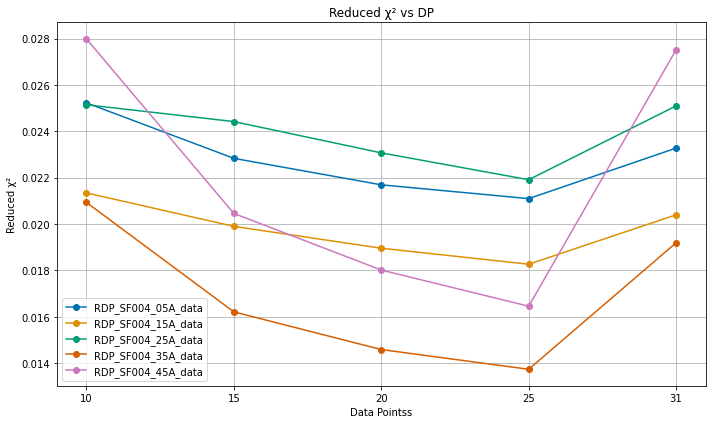

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# choose a colourblind-friendly palette
sns.set_palette("colorblind")

def plot_all_folders_vs_dp(df_by_folder, metric, title, ylabel):
    """Plot a metric vs DP for all folders on the same graph."""
    plt.figure(figsize=(10, 6))
    
    for folder_name, df in df_by_folder.items():
        # Drop rows with NA in DP column
        df_clean = df.dropna(subset=['DP'])
        if len(df_clean) == 0:
            continue
        # Sort by DP to ensure lines connect properly
        df_sorted = df_clean.sort_values('DP')
        plt.plot(df_sorted['DP'], 
                 df_sorted[metric], 
                 marker='o', 
                 linestyle='-',
                 label=folder_name)
    
    plt.xlabel('Data Pointss')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

# Three graphs comparing all folders
plot_all_folders_vs_dp(df_by_folder, 'R2_total', 'R² Total vs DP', 'R² Total')
plt.savefig('all_folders_R2_total_vs_DP.png')
plt.show()

plot_all_folders_vs_dp(df_by_folder, 'R2_log_total', 'R² Log Total vs DP', 'R² Log Total')
plt.savefig('all_folders_R2_log_total_vs_DP.png')
plt.show()

plot_all_folders_vs_dp(df_by_folder, 'Reduced_chi2', 'Reduced χ² vs DP', 'Reduced χ²')
plt.savefig('all_folders_Reduced_chi2_vs_DP.png')
plt.show()